# 🎓 Student Scores — Red Neuronal Feed-Forward con PyTorch
## Reto proyecto 1 · Construye una feed-forward network con PyTorch

---

Este notebook entrena una red neuronal feed-forward para predecir las puntuaciones  
de estudiantes en función de sus horas de estudio.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración del dataset |
| 2️⃣ | Preparación y partición (75% train / 25% test) |
| 3️⃣ | Conversión a tensores PyTorch |
| 4️⃣ | Construcción de la red neuronal (2 capas ocultas: 64 → 32) |
| 5️⃣ | Entrenamiento con MSELoss + Adam (200 épocas) |
| 6️⃣ | Evaluación — R², MAE, RMSE |

> **Dataset:** `student_scores.csv` — 25 registros · 2 columnas  
> **Objetivo:** predecir `Scores` a partir de `Hours` (regresión)  
> **Ruta:** `/workspace/student_scores.csv`


---
## 0. Importación de librerías


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Reproducibilidad ─────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
# Para reproducibilidad estricta en GPU (no requerido por el enunciado):
#   torch.cuda.manual_seed_all(42)
#   torch.use_deterministic_algorithms(True)   # puede ralentizar en GPU
# En este notebook se ejecuta en CPU, por lo que lo anterior no aplica.

# ── Configuración centralizada ────────────────────────────────────────────
# INPUT_PATH lee de variable de entorno si está definida; si no, usa la
# ruta absoluta requerida por el enunciado.
#   export STUDENT_SCORES_PATH=/ruta/alternativa/student_scores.csv
INPUT_PATH = os.environ.get("STUDENT_SCORES_PATH",
                             "workspace/student_scores.csv")
EPOCHS      = 200
HIDDEN1     = 64
HIDDEN2     = 32
LR           = 0.01     # learning rate inicial para Adam
ADAM_BETAS   = (0.9, 0.999)  # momentos de 1er y 2º orden (valores por defecto)
                              # β1=0.9: suaviza el gradiente acumulado
                              # β2=0.999: suaviza el cuadrado del gradiente
ADAM_WD      = 0.0       # weight_decay (L2): 0 → sin regularización explícita
                          # Aumentar (p.ej. 1e-4) si hay sobreajuste
USE_DATALOADER = False    # True → mini-batches con DataLoader (útil si n > 1000)
                          # Para n=25 el batch completo es más eficiente

# ── Flags de mejoras opcionales ───────────────────────────────────────────
USE_WEIGHT_INIT = True   # True → inicialización He (Kaiming) en capas ocultas
USE_SCHEDULER   = True   # True → CosineAnnealingLR para LR decreciente
RUN_CV          = True   # True → validación cruzada K-Fold adicional

print("✅ Librerías cargadas correctamente.")
print(f"   PyTorch {torch.__version__}")
print(f"📂 INPUT_PATH:      {INPUT_PATH}")
print(f"   USE_WEIGHT_INIT={USE_WEIGHT_INIT}  "
      f"USE_SCHEDULER={USE_SCHEDULER}  RUN_CV={RUN_CV}")


✅ Librerías cargadas correctamente.
   PyTorch 2.10.0+cpu
📂 INPUT_PATH:      workspace/student_scores.csv
   USE_WEIGHT_INIT=True  USE_SCHEDULER=True  RUN_CV=True


---
## 1. Carga y Exploración del Dataset


In [2]:
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {INPUT_PATH}\n"
        "   Coloca student_scores.csv en /workspace/ antes de ejecutar."
    )

dataset = pd.read_csv(INPUT_PATH)

print(f"📐 Dimensiones: {dataset.shape}")
print(f"\n📋 Primeras filas:")
print(dataset.head())
print(f"\n📊 Estadísticas descriptivas:")
print(dataset.describe().round(2))
print(f"\n🔍 Valores nulos: {dataset.isnull().sum().sum()}")


📐 Dimensiones: (25, 2)

📋 Primeras filas:
   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30

📊 Estadísticas descriptivas:
       Hours  Scores
count  25.00   25.00
mean    5.01   51.48
std     2.53   25.29
min     1.10   17.00
25%     2.70   30.00
50%     4.80   47.00
75%     7.40   75.00
max     9.20   95.00

🔍 Valores nulos: 0


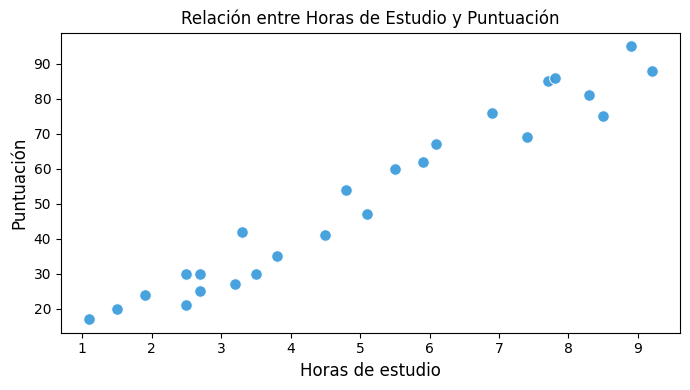

In [3]:
# Visualización de la relación Hours → Scores
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dataset["Hours"], dataset["Scores"],
           color="#3498db", s=70, edgecolors="white", linewidth=0.8, alpha=0.9)
ax.set_xlabel("Horas de estudio", fontsize=12)
ax.set_ylabel("Puntuación", fontsize=12)
ax.set_title("Relación entre Horas de Estudio y Puntuación")
plt.tight_layout()
plt.show()


---
## 2. Preparación y Partición del Dataset


In [4]:
X = dataset[["Hours"]].values.astype(np.float32)   # shape (25, 1)
y = dataset[["Scores"]].values.astype(np.float32)   # shape (25, 1)

# test_size=0.25 → 75/25 nominal.
# Con n=25, 25 × 0.25 = 6.25 → redondeado a 7 muestras de test.
# Proporción real: 18 train / 7 test ≈ 72% / 28%.
# Esta ligera variación (±3 p.p.) es inherente al tamaño discreto del dataset.
#
# shuffle=True (explícito): mezcla aleatoria antes de la partición.
# En series temporales se usaría shuffle=False para respetar el orden cronológico;
# aquí los datos no tienen dependencia temporal, por lo que shuffle=True es correcto.
# train_test_split no admite stratify para regresión continua (solo clasificación).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    shuffle=True,        # mezcla explícita antes de particionar
    random_state=42
)

print(f"📊 División del dataset:")
print(f"  Train: {len(X_train)} registros  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test)}  registros  ({len(X_test)/len(X)*100:.1f}%)")
print(f"  (Objetivo 75/25 — proporción real: "
      f"{len(X_train)/len(X)*100:.1f}/{len(X_test)/len(X)*100:.1f}% "
      f"por tamaño discreto del dataset)")


📊 División del dataset:
  Train: 18 registros  (72.0%)
  Test:  7  registros  (28.0%)
  (Objetivo 75/25 — proporción real: 72.0/28.0% por tamaño discreto del dataset)


---
## 3. Conversión a Tensores PyTorch


In [5]:
X_train_t = torch.tensor(X_train)
X_test_t  = torch.tensor(X_test)
y_train_t = torch.tensor(y_train)
y_test_t  = torch.tensor(y_test)

print(f"✅ Tensores creados:")
print(f"  X_train_t: {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"  y_train_t: {y_train_t.shape}  dtype={y_train_t.dtype}")
print(f"  X_test_t:  {X_test_t.shape}   dtype={X_test_t.dtype}")
print(f"  y_test_t:  {y_test_t.shape}   dtype={y_test_t.dtype}")

# ── Nota sobre DataLoader ────────────────────────────────────────────────
# Para datasets pequeños como este (n=25) el entrenamiento en batch completo
# (full-batch) es óptimo: usa toda la información en cada paso del gradiente.
# Si USE_DATALOADER=True (celda 0) o el dataset creciera a >1000 filas,
# mini-batches mejorarían la velocidad y la generalización:
#
#   from torch.utils.data import TensorDataset, DataLoader
#   ds = TensorDataset(X_train_t, y_train_t)
#   loader = DataLoader(ds, batch_size=32, shuffle=True)
#   for X_batch, y_batch in loader:
#       ...  # reemplaza el bucle de entrenamiento actual
if USE_DATALOADER:
    from torch.utils.data import TensorDataset, DataLoader
    train_ds     = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    print(f"\n  DataLoader activado: {len(train_loader)} mini-batches de ~8 muestras.")
else:
    train_loader = None
    print(f"\n  Entrenamiento en batch completo (n={len(X_train_t)}).")
    print(f"  (USE_DATALOADER=False — adecuado para n=25)")


✅ Tensores creados:
  X_train_t: torch.Size([18, 1])  dtype=torch.float32
  y_train_t: torch.Size([18, 1])  dtype=torch.float32
  X_test_t:  torch.Size([7, 1])   dtype=torch.float32
  y_test_t:  torch.Size([7, 1])   dtype=torch.float32

  Entrenamiento en batch completo (n=18).
  (USE_DATALOADER=False — adecuado para n=25)


---
## 4. Construcción de la Red Neuronal Feed-Forward

Arquitectura:

| Capa | Neuronas entrada | Neuronas salida | Activación |
|------|:----------------:|:---------------:|:----------:|
| Entrada → Oculta 1 | 1 | 64 | ReLU |
| Oculta 1 → Oculta 2 | 64 | 32 | ReLU |
| Oculta 2 → Salida | 32 | 1 | — (lineal) |


In [6]:
# ── Por qué una clase que hereda de nn.Module ────────────────────────────
# En PyTorch toda red neuronal se define heredando de nn.Module.
# nn.Module gestiona parámetros entrenables, modo train/eval e integración
# con el optimizador. nn.Sequential es más limitado y no permite lógica
# condicional en forward ni inicialización personalizada.

OUTPUT_DIM   = 1          # salida escalar para regresión simple
ACTIVATION   = nn.ReLU   # clase de activación — cambiar aquí para experimentar
                          # Alternativas: nn.Tanh, nn.LeakyReLU, nn.ELU, nn.GELU


class StudentScoreNet(nn.Module):
    """
    Red neuronal feed-forward parametrizable para regresión.

    Arquitectura:
        Linear(input_dim → h1) → activation()
        Linear(h1 → h2)        → activation()
        Linear(h2 → output_dim)   (salida lineal, sin activación)

    Args:
        input_dim:        número de features de entrada.
        h1:               neuronas en la primera capa oculta (64).
        h2:               neuronas en la segunda capa oculta (32).
        output_dim:       neuronas de salida (1 para regresión escalar).
        activation:       clase de activación (por defecto nn.ReLU).
        use_weight_init:  He + Xavier si True; init por defecto si False.
    """

    def __init__(self, input_dim: int, h1: int, h2: int,
                 output_dim: int = OUTPUT_DIM,
                 activation: type = nn.ReLU,
                 use_weight_init: bool = True) -> None:
        super().__init__()
        self.fc1  = nn.Linear(input_dim, h1)
        self.fc2  = nn.Linear(h1, h2)
        self.fc3  = nn.Linear(h2, output_dim)
        self.act  = activation()   # instanciar la clase de activación

        if use_weight_init:
            # He (Kaiming) para ReLU y variantes; Xavier para salida lineal.
            nonlin = "relu" if activation in (nn.ReLU, nn.LeakyReLU) else "tanh"
            nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity=nonlin)
            nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity=nonlin)
            nn.init.xavier_uniform_(self.fc3.weight)
            for layer in [self.fc1, self.fc2, self.fc3]:
                nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Propagación hacia adelante.

        Args:
            x: tensor con shape (batch_size, input_dim).
        Returns:
            Tensor con shape (batch_size, output_dim).
        """
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.fc3(x)


model = StudentScoreNet(
    input_dim=1, h1=HIDDEN1, h2=HIDDEN2,
    output_dim=OUTPUT_DIM,
    activation=ACTIVATION,
    use_weight_init=USE_WEIGHT_INIT
)
print(model)
print(f"\n📊 Parámetros totales: "
      f"{sum(p.numel() for p in model.parameters()):,}")
print(f"   Activación:        {ACTIVATION.__name__}")
print(f"   Salida:            {OUTPUT_DIM} neurona(s) — regresión escalar")
print(f"   Inicialización:    "
      f"{'He + Xavier' if USE_WEIGHT_INIT else 'PyTorch por defecto'}")


StudentScoreNet(
  (fc1): Linear(in_features=1, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (act): ReLU()
)

📊 Parámetros totales: 2,241
   Activación:        ReLU
   Salida:            1 neurona(s) — regresión escalar
   Inicialización:    He + Xavier


---
## 5. Entrenamiento de la Red Neuronal


In [7]:
criterion = nn.MSELoss()
optimizer = Adam(
    model.parameters(),
    lr=LR,
    betas=ADAM_BETAS,    # (β1, β2) — suavizado de gradiente y su cuadrado
    weight_decay=ADAM_WD # L2 regularización; 0 → sin penalización de pesos
)

if USE_SCHEDULER:
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

loss_history = []
mae_history  = []
lr_history   = []

model.train()
for epoch in range(1, EPOCHS + 1):
    if USE_DATALOADER and train_loader is not None:
        # Mini-batch: acumular loss para el print (promedio de los batches)
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward(); optimizer.step()
            batch_losses.append(loss.item())
        loss_val = np.mean(batch_losses)
        # MAE sobre train completo tras la época
        with torch.no_grad():
            mae_val = (model(X_train_t) - y_train_t).abs().mean().item()
    else:
        # Full-batch (por defecto para n=25)
        optimizer.zero_grad()
        predictions = model(X_train_t)
        loss = criterion(predictions, y_train_t)
        loss.backward(); optimizer.step()
        loss_val = loss.item()
        with torch.no_grad():
            mae_val = (predictions - y_train_t).abs().mean().item()

    if USE_SCHEDULER:
        scheduler.step()

    loss_history.append(loss_val)
    mae_history.append(mae_val)
    lr_history.append(optimizer.param_groups[0]["lr"])

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Época {epoch:>3}/{EPOCHS}  "
              f"MSE: {loss_val:>8.2f}  "
              f"MAE: {mae_val:>6.2f}  "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

print(f"\n✅ Entrenamiento completado.")
print(f"   MSE final:  {loss_history[-1]:.2f}")
print(f"   MAE final:  {mae_history[-1]:.2f}")
print(f"   LR final:   {lr_history[-1]:.2e}")
print(f"   β1={ADAM_BETAS[0]}  β2={ADAM_BETAS[1]}  "
      f"weight_decay={ADAM_WD}")


  Época   1/200  MSE:  4138.12  MAE:  57.99  LR: 1.00e-02
  Época  20/200  MSE:   223.71  MAE:  12.47  LR: 9.76e-03
  Época  40/200  MSE:    42.86  MAE:   5.54  LR: 9.05e-03
  Época  60/200  MSE:    31.94  MAE:   5.39  LR: 7.94e-03
  Época  80/200  MSE:    32.08  MAE:   5.36  LR: 6.55e-03
  Época 100/200  MSE:    31.84  MAE:   5.38  LR: 5.00e-03
  Época 120/200  MSE:    31.77  MAE:   5.37  LR: 3.46e-03
  Época 140/200  MSE:    31.74  MAE:   5.37  LR: 2.07e-03
  Época 160/200  MSE:    31.73  MAE:   5.36  LR: 9.64e-04
  Época 180/200  MSE:    31.72  MAE:   5.36  LR: 2.54e-04
  Época 200/200  MSE:    31.72  MAE:   5.36  LR: 1.00e-05

✅ Entrenamiento completado.
   MSE final:  31.72
   MAE final:  5.36
   LR final:   1.00e-05
   β1=0.9  β2=0.999  weight_decay=0.0


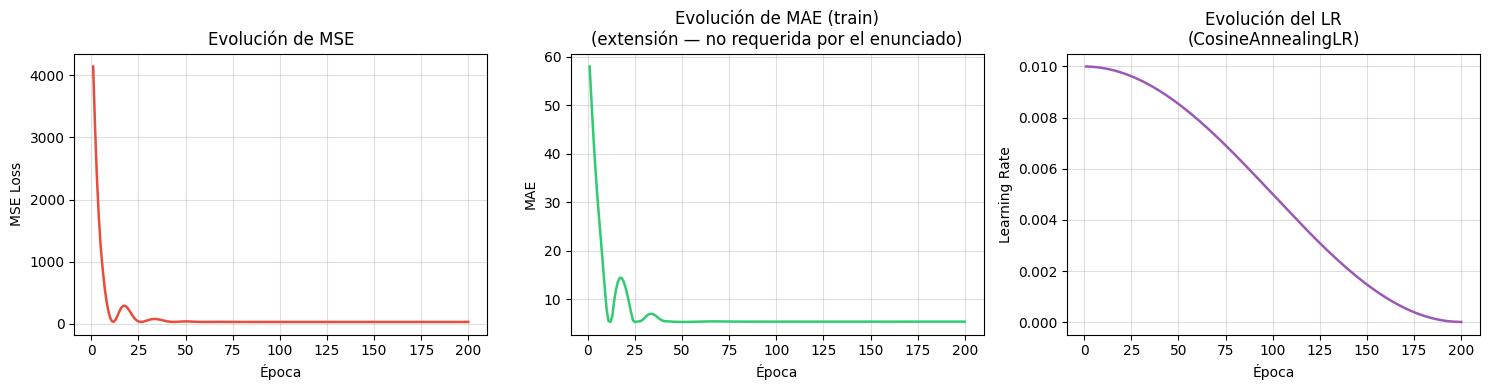

In [8]:
n_panels = 2 + (1 if USE_SCHEDULER else 0)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
if n_panels == 2: axes = list(axes)   # convert to list for uniform indexing

axes[0].plot(range(1, EPOCHS+1), loss_history, color="#e74c3c", linewidth=1.8)
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Evolución de MSE"); axes[0].grid(True, alpha=0.4)

# MAE por época — convergencia complementaria al MSE
axes[1].plot(range(1, EPOCHS+1), mae_history, color="#2ecc71", linewidth=1.8)
axes[1].set_xlabel("Época"); axes[1].set_ylabel("MAE")
axes[1].set_title("Evolución de MAE (train)\n(extensión — no requerida por el enunciado)")
axes[1].grid(True, alpha=0.4)

if USE_SCHEDULER:
    axes[2].plot(range(1, EPOCHS+1), lr_history, color="#9b59b6", linewidth=1.8)
    axes[2].set_xlabel("Época"); axes[2].set_ylabel("Learning Rate")
    axes[2].set_title("Evolución del LR\n(CosineAnnealingLR)")
    axes[2].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


### 6.1 Función de métricas reutilizable

Encapsular el cálculo en `eval_metrics()` permite aplicar las mismas métricas  
a train, test y CV de forma consistente y sin repetir código.


In [9]:
def eval_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                  label: str = "") -> dict:
    """Calcula R², MAE y RMSE e imprime un resumen formateado.

    Args:
        y_true: valores reales (numpy array).
        y_pred: valores predichos (numpy array).
        label:  etiqueta del conjunto (p.ej. 'TEST', 'TRAIN').

    Returns:
        dict con claves 'r2', 'mae', 'rmse'.
    """
    r2_   = r2_score(y_true, y_pred)
    mae_  = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))

    header = f"📊 Métricas{' — ' + label if label else ''}:"
    print(header)
    print(f"  {'Métrica':<42} {'Valor':>10}  {'(reporte)':>10}")
    print("  " + "─" * 66)
    print(f"  {'R²  (Coef. de determinación):':<42} {r2_:>10.4f}  {r2_:>9.2f}")
    print(f"  {'MAE (Error absoluto medio):':<42} {mae_:>10.4f}  {mae_:>9.2f}")
    print(f"  {'RMSE (Raíz del error cuadrático medio):':<42} {rmse_:>10.4f}  {rmse_:>9.2f}")
    return {"r2": r2_, "mae": mae_, "rmse": rmse_}

print("✅ Función eval_metrics() definida.")


✅ Función eval_metrics() definida.


---
## 6. Evaluación del Modelo


In [10]:
model.eval()
with torch.no_grad():
    y_pred_t     = model(X_test_t)
    y_pred_train = model(X_train_t)

y_pred = y_pred_t.numpy()
y_true = y_test_t.numpy()

# ── Métricas en test (requisito del enunciado) ────────────────────────────
metrics_test  = eval_metrics(y_true, y_pred, label="TEST")
r2   = metrics_test["r2"]
mae  = metrics_test["mae"]
rmse = metrics_test["rmse"]

# ── Métricas en train (comparativa adicional) ─────────────────────────────
print()
metrics_train = eval_metrics(y_train_t.numpy(), y_pred_train.numpy(), label="TRAIN")

print()
delta_r2 = metrics_train["r2"] - r2
print(f"  Δ R² (train - test): {delta_r2:+.4f} "
      f"{'— sin sobreajuste notable' if abs(delta_r2) < 0.05 else '— posible sobreajuste'}")

print()
if r2 >= 0.90:
    print("✅ R² ≥ 0.90 — el modelo explica muy bien la varianza de las puntuaciones.")
elif r2 >= 0.75:
    print("✅ R² ≥ 0.75 — buen ajuste para un dataset tan pequeño (n=25).")
else:
    print("⚠️  R² < 0.75 — ajuste moderado; considera más épocas o un LR distinto.")


📊 Métricas — TEST:
  Métrica                                         Valor   (reporte)
  ──────────────────────────────────────────────────────────────────
  R²  (Coef. de determinación):                  0.9540       0.95
  MAE (Error absoluto medio):                    4.4755       4.48
  RMSE (Raíz del error cuadrático medio):        4.9221       4.92

📊 Métricas — TRAIN:
  Métrica                                         Valor   (reporte)
  ──────────────────────────────────────────────────────────────────
  R²  (Coef. de determinación):                  0.9506       0.95
  MAE (Error absoluto medio):                    5.3638       5.36
  RMSE (Raíz del error cuadrático medio):        5.6322       5.63

  Δ R² (train - test): -0.0034 — sin sobreajuste notable

✅ R² ≥ 0.90 — el modelo explica muy bien la varianza de las puntuaciones.


### 6.2 Validación Cruzada K-Fold — estimación más robusta del rendimiento

> ⚠️ **Esta sección es una extensión opcional — no está requerida por el enunciado.**  
> Actívala con `RUN_CV = True` en la celda 0.  
> El requisito oficial del proyecto queda cubierto únicamente con la sección 6.1.

Con solo 25 muestras, un único split 75/25 puede variar ±0.05 en R² dependiendo  
de qué 7 puntos caigan en test. `KFold(k=5)` entrena 5 modelos independientes  
y reporta media ± desviación estándar de R², MAE y RMSE para estimar la  
**estabilidad real** del modelo frente a distintas particiones.


In [11]:
if RUN_CV:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2, cv_mae, cv_rmse = [], [], []

    X_all = torch.tensor(dataset[["Hours"]].values.astype(np.float32))
    y_all = torch.tensor(dataset[["Scores"]].values.astype(np.float32))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all), start=1):
        # Modelo fresco para cada fold
        fold_model = StudentScoreNet(1, HIDDEN1, HIDDEN2,
                                     use_weight_init=USE_WEIGHT_INIT)
        fold_opt   = Adam(fold_model.parameters(), lr=LR)
        fold_crit  = nn.MSELoss()
        if USE_SCHEDULER:
            fold_sch = CosineAnnealingLR(fold_opt, T_max=EPOCHS, eta_min=1e-5)

        # Entrenamiento del fold
        fold_model.train()
        for _ in range(EPOCHS):
            fold_opt.zero_grad()
            loss = fold_crit(fold_model(X_all[train_idx]),
                             y_all[train_idx])
            loss.backward(); fold_opt.step()
            if USE_SCHEDULER: fold_sch.step()

        # Evaluación del fold
        fold_model.eval()
        with torch.no_grad():
            yp = fold_model(X_all[val_idx]).numpy()
        yt = y_all[val_idx].numpy()
        m = eval_metrics(yt, yp, label=f"Fold {fold}/5")
        cv_r2.append(m["r2"]); cv_mae.append(m["mae"]); cv_rmse.append(m["rmse"])
        print()

    print(f"\n📊 Resultados K-Fold (k=5):\n")
    print(f"  {'Métrica':<8}  {'Media':>8}  {'Std':>8}")
    print("  " + "─" * 28)
    for nombre, vals in [("R²", cv_r2), ("MAE", cv_mae), ("RMSE", cv_rmse)]:
        print(f"  {nombre:<8}  {np.mean(vals):>8.4f}  {np.std(vals):>8.4f}")

    print(f"\n  💡 R² medio CV:  {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
    print(f"  💡 Comparar con el split único (sección 6.1): "
          f"R²={r2:.4f}")
    if abs(r2 - np.mean(cv_r2)) < 0.05:
        print("  ✅ Split único y CV son consistentes — "
              "el split no introduce sesgo notable.")
    else:
        print("  ⚠️  Diferencia notable entre split único y CV — "
              "preferir R² CV como estimación de referencia.")
else:
    print("ℹ️  Validación cruzada omitida (RUN_CV=False).")


📊 Métricas — Fold 1/5:
  Métrica                                         Valor   (reporte)
  ──────────────────────────────────────────────────────────────────
  R²  (Coef. de determinación):                  0.9690       0.97
  MAE (Error absoluto medio):                    4.0316       4.03
  RMSE (Raíz del error cuadrático medio):        4.2721       4.27

📊 Métricas — Fold 2/5:
  Métrica                                         Valor   (reporte)
  ──────────────────────────────────────────────────────────────────
  R²  (Coef. de determinación):                  0.7383       0.74
  MAE (Error absoluto medio):                    4.8543       4.85
  RMSE (Raíz del error cuadrático medio):        5.1704       5.17

📊 Métricas — Fold 3/5:
  Métrica                                         Valor   (reporte)
  ──────────────────────────────────────────────────────────────────
  R²  (Coef. de determinación):                  0.9167       0.92
  MAE (Error absoluto medio):                    

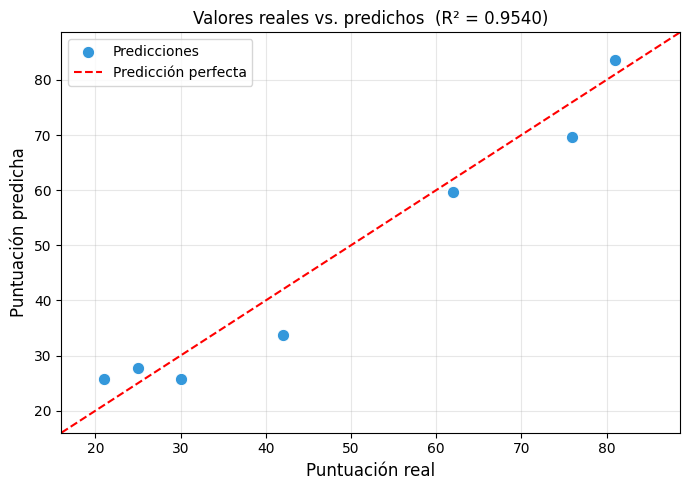

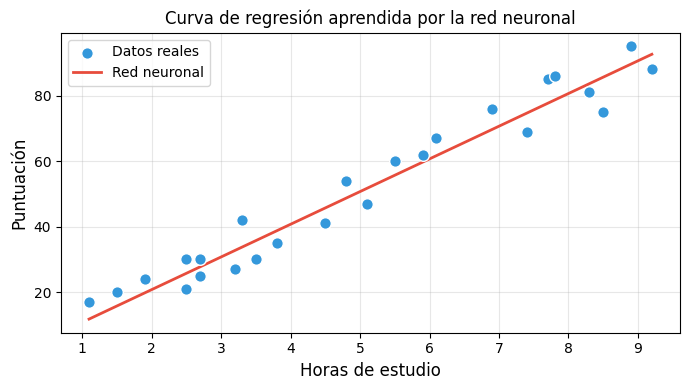

In [12]:
# Predicciones vs valores reales
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_true, y_pred,
           color="#3498db", s=80, edgecolors="white", linewidth=0.8,
           label="Predicciones", zorder=3)
lim = [min(y_true.min(), y_pred.min()) - 5,
       max(y_true.max(), y_pred.max()) + 5]
ax.plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Puntuación real", fontsize=12)
ax.set_ylabel("Puntuación predicha", fontsize=12)
ax.set_title(f"Valores reales vs. predichos  (R² = {r2:.4f})")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Curva de regresión sobre todos los datos
X_range = np.linspace(dataset["Hours"].min(), dataset["Hours"].max(), 200)
X_range_t = torch.tensor(X_range.reshape(-1, 1).astype(np.float32))
with torch.no_grad():
    y_range_pred = model(X_range_t).numpy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dataset["Hours"], dataset["Scores"],
           color="#3498db", s=70, edgecolors="white", label="Datos reales", zorder=3)
ax.plot(X_range, y_range_pred, color="#e74c3c", linewidth=2, label="Red neuronal")
ax.set_xlabel("Horas de estudio", fontsize=12)
ax.set_ylabel("Puntuación", fontsize=12)
ax.set_title("Curva de regresión aprendida por la red neuronal")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
